In [1]:
from pyLOCO.helpers import load_config
import os
import h5py
config_path = os.path.abspath("pyloco_config.py")
load_config(config_path=config_path)
from pyLOCO.pyloco_test import pyloco, remove_bad_bpms
from pyLOCO.analysis import plot_beta, plot_eta, plot_matrices

import numpy as np
import at


ring = at.load_lattice('./data/p3_low_beta.mat')
elements_ind = at.get_refpts(ring, "*")
_, _, twiss = at.get_optics(ring, elements_ind)
# ============================================================================== #
#                Prepare quadrupoles,skews, correctors, bpms, cavity indices
# ============================================================================== #

quad_indices = np.load('./data/quad_ind.npy')
skew_ord = np.load('./data/skew_ind.npy')

data = np.load('./data/CMstep.npz')
CMstep = [data['hor'], data['ver']]

def load_names(filename):
    with open(filename, 'r') as file:
        names = [line.strip() for line in file.readlines()]
    return names

HCM_names = load_names("./data/HCM_names.txt")
VCM_names = load_names("./data/VCM_names.txt")
BPMs_names = load_names("./data/BPM_names.txt")

cor_ind_x = []
for i, elem in enumerate(ring):
    if getattr(elem, 'CommonName', None) in HCM_names:
        cor_ind_x.append(i)

cor_ind_y = []
for i, elem in enumerate(ring):
    if getattr(elem, 'CommonName', None) in VCM_names:
        cor_ind_y.append(i)

used_bpm = []
for i, elem in enumerate(ring):
    if getattr(elem, 'CommonName', None) in BPMs_names:
        used_bpm.append(i)

#used_bpm = at.get_refpts(ring, at.elements.Monitor)

sorted_cor_ind_x = np.sort(cor_ind_x)
sorted_cor_ind_y = np.sort(cor_ind_y)
Corords = [sorted_cor_ind_x, sorted_cor_ind_y]
CAVords = at.get_refpts(ring, at.elements.RFCavity)

# --- Load Measurments ---
with h5py.File("./data/measured_orm_loco.h5", "r") as f:
    measured_orm = np.array(f["response_matrix"]) # in meter [BPMs X Cor]

with h5py.File("./data/measured_dispersion_loco.h5", "r") as f:  # in meter
    measured_eta_x_ = np.array(f["measured_eta_x"])
    measured_eta_y_ = np.array(f["measured_eta_y"])
    attrs_eta = dict(f.attrs)

with h5py.File("./data/measured_BPM_noise_loco.h5", "r") as f:  # in meter
    Noise_BPMx = np.array(f["Noise_BPMx"])
    Noise_BPMy = np.array(f["Noise_BPMy"])
    attrs_noise = dict(f.attrs)


# ============================================================================== #
#               Remove bad BPMs from measurment data
# ============================================================================== #

bad_bpm_ind = [1973, 5639, 5681, 5825, 6011, 6087, 6197, 6297, 6311, 7641]
bad_bpm_positions = np.array([24, 104, 108, 111, 123, 138, 144, 153, 161,162, 243])
Noise_BPMx_cleaned = np.delete(Noise_BPMx, bad_bpm_positions)
Noise_BPMy_cleaned = np.delete(Noise_BPMy, bad_bpm_positions)
sigma_w = np.concatenate((Noise_BPMx_cleaned, Noise_BPMy_cleaned))[:, np.newaxis]  # Note: weight matrix shape for pyloco
used_bpms_ords = np.delete(used_bpm, bad_bpm_positions)


measured_eta_x = np.delete(measured_eta_x_, bad_bpm_positions)
measured_eta_y = np.delete(measured_eta_y_, bad_bpm_positions)


measured_orm , removed = remove_bad_bpms(measured_orm,
                                     bad_bpm_positions,
                                     total_bpms=len(used_bpm),
                                     axis=0,
                                     input_type="positions")


==== Iteration 1/8 – LM ====
[Jacobian] File exists, but recomputing as requested (force_recompute=True).
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs2.txt'
Normal quad Jacobian: 43.8 s
[Jacobian] Saved normal-quadrupole Jacobian to output/jacobians/quads/J_quads_iter1_9.868774242500396e-05urad_-3000.0Hz.h5
   No outliers in the data set.
Initial Chi²: 2.4559e+04


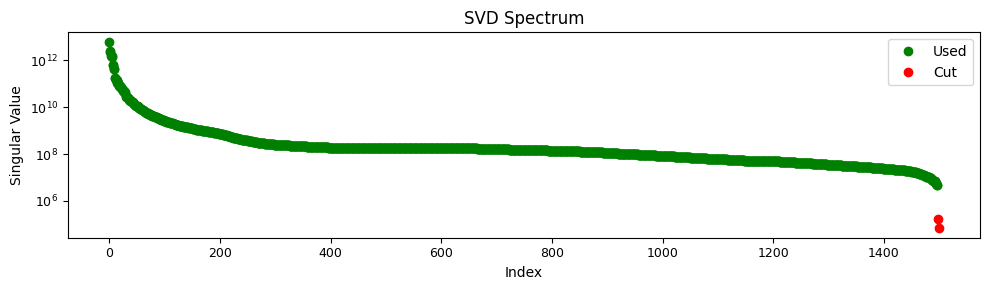

  LM inner 1: chi² 6.5528e+02 (previous 2.4559e+04), λ=0.001
Chi² after correction: 6.5528e+02

==== Iteration 2/8 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 2)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs2.txt'
Normal quad Jacobian: 44.0 s
   No outliers in the data set.
Initial Chi²: 6.5528e+02


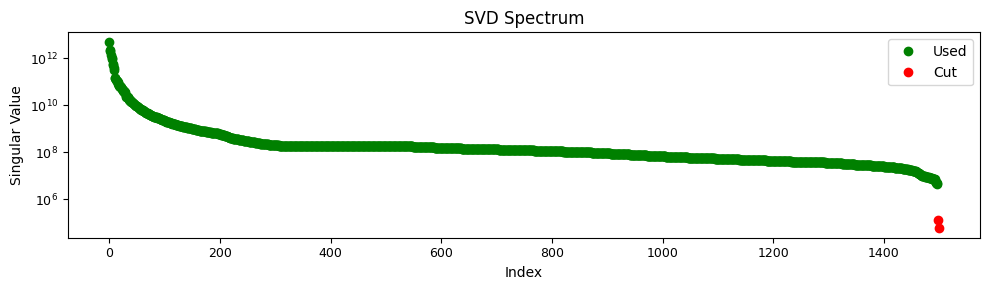

  LM inner 1: chi² 7.2323e+00 (previous 6.5528e+02), λ=0.001
Chi² after correction: 7.2323e+00

==== Iteration 3/8 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 3)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs2.txt'
Normal quad Jacobian: 43.5 s
   No outliers in the data set.
Initial Chi²: 7.2323e+00


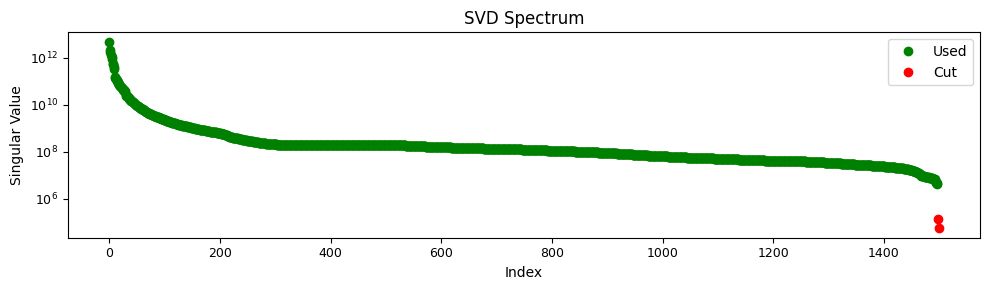

  LM inner 1: chi² 5.3295e+00 (previous 7.2323e+00), λ=0.001
Chi² after correction: 5.3295e+00

==== Iteration 4/8 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 4)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs2.txt'
Normal quad Jacobian: 43.5 s
   std(Model-Measurement) = 0.003684 mm (with outliers)
   2 outliers removed out of 97055 points (> 10 sigma) (2 first test + 0 second test).
Initial Chi²: 5.3295e+00


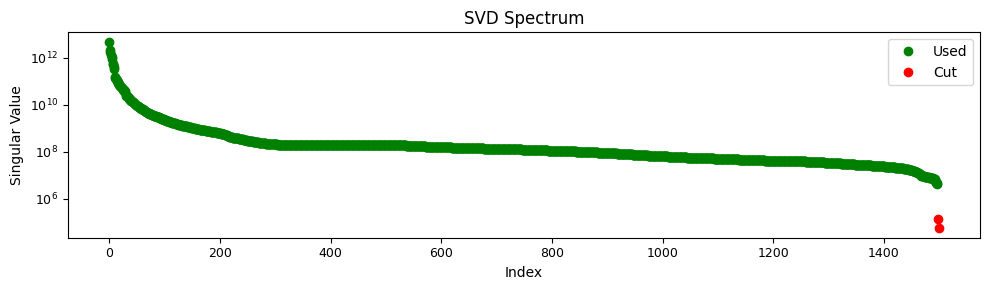

  LM inner 1: chi² 5.1951e+00 (previous 5.3295e+00), λ=0.001
Chi² after correction: 5.1940e+00

==== Iteration 5/8 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 5)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs2.txt'
Normal quad Jacobian: 43.2 s
   std(Model-Measurement) = 0.003617 mm (with outliers)
   2 outliers removed out of 97055 points (> 10 sigma) (2 first test + 0 second test).
Initial Chi²: 5.1940e+00


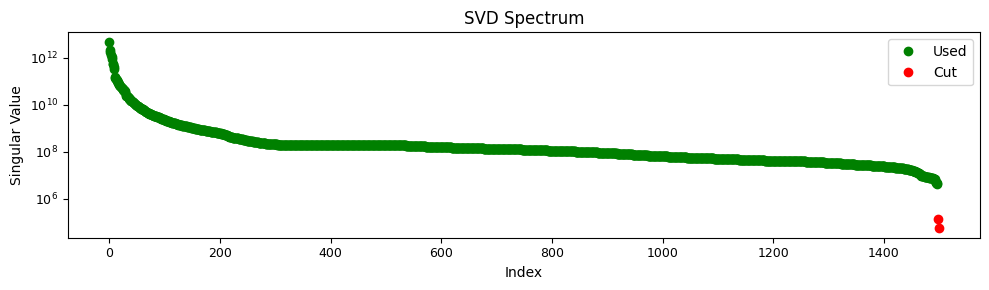

  LM inner 1: chi² 5.1525e+00 (previous 5.1940e+00), λ=0.001
Chi² after correction: 5.1525e+00

==== Iteration 6/8 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 6)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs2.txt'
Normal quad Jacobian: 43.1 s
   std(Model-Measurement) = 0.003599 mm (with outliers)
   2 outliers removed out of 97055 points (> 10 sigma) (2 first test + 0 second test).
Initial Chi²: 5.1525e+00


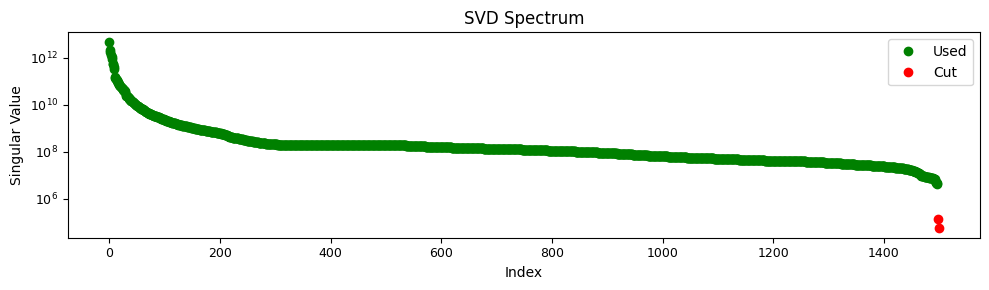

  LM inner 1: chi² 5.1327e+00 (previous 5.1525e+00), λ=0.001
Chi² after correction: 5.1327e+00

==== Iteration 7/8 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 7)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs2.txt'
Normal quad Jacobian: 45.1 s
   std(Model-Measurement) = 0.003591 mm (with outliers)
   2 outliers removed out of 97055 points (> 10 sigma) (2 first test + 0 second test).
Initial Chi²: 5.1327e+00


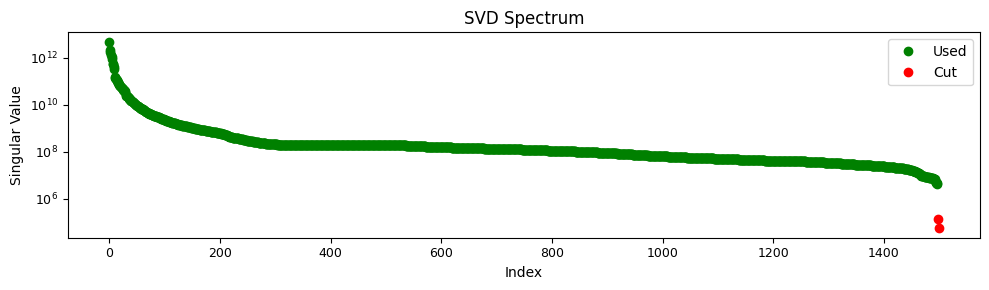

  LM inner 1: chi² 5.1205e+00 (previous 5.1327e+00), λ=0.001
Chi² after correction: 5.1205e+00

==== Iteration 8/8 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 8)...
[calculate_quads_jacobian] Logs saved to '/Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs2.txt'
Normal quad Jacobian: 47.9 s
   std(Model-Measurement) = 0.003586 mm (with outliers)
   2 outliers removed out of 97055 points (> 10 sigma) (2 first test + 0 second test).
Initial Chi²: 5.1205e+00


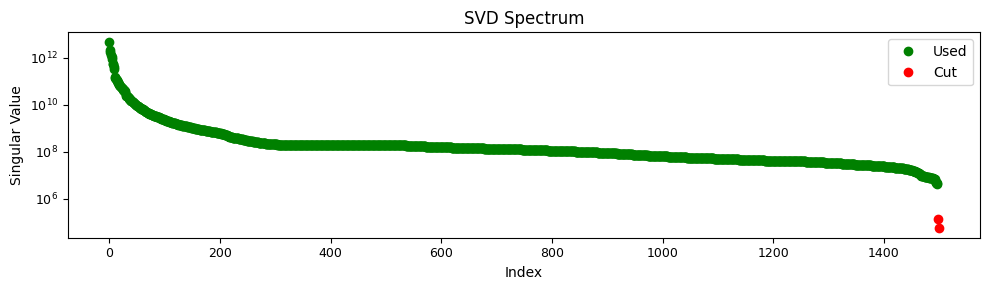

  LM inner 1: chi² 5.1119e+00 (previous 5.1205e+00), λ=0.001
Chi² after correction: 5.1119e+00
LOCO LM completed! :).


In [2]:
import numpy as np
from pyloco_config import FitInitConfig, fixed_parameters, loco_options

fit_cfg = FitInitConfig()

# --- define arguments ---

nHorCOR    = len(Corords[0])
nVerCOR    = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter      = 8
fit_list   = [
    "quads",
    "hbpm_gain",
    "vbpm_gain",
    "hcor_cal",
    "vcor_cal",
    "HCMEnergyShift",
]
remove_coupling_ = True
fit_results, fit_dict, ring,_,_,_,_,_ = pyloco(
    ring,
    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=None,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=loco_options.includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=loco_options.hor_dispersion_weight,
    ver_dispersion_weight=loco_options.ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=fixed_parameters.rfstep,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list= fit_list,
    quad_individuals=loco_options.quad_individuals,
    skew_individuals=loco_options.skew_individuals,
    tilt_individuals=loco_options.tilt_individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method=loco_options.svd_selection_method,
    svd_threshold=loco_options.svd_threshold,
    cut_=loco_options.cut_,
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength=loco_options.fixedpathlength,
    fit_cfg=fit_cfg,
)

# --- save results ---
#np.save("./output/loco_lm_fit_results_iterations.npy", fit_results)

Lattice tune after loco : [0.12029783 0.30368832]


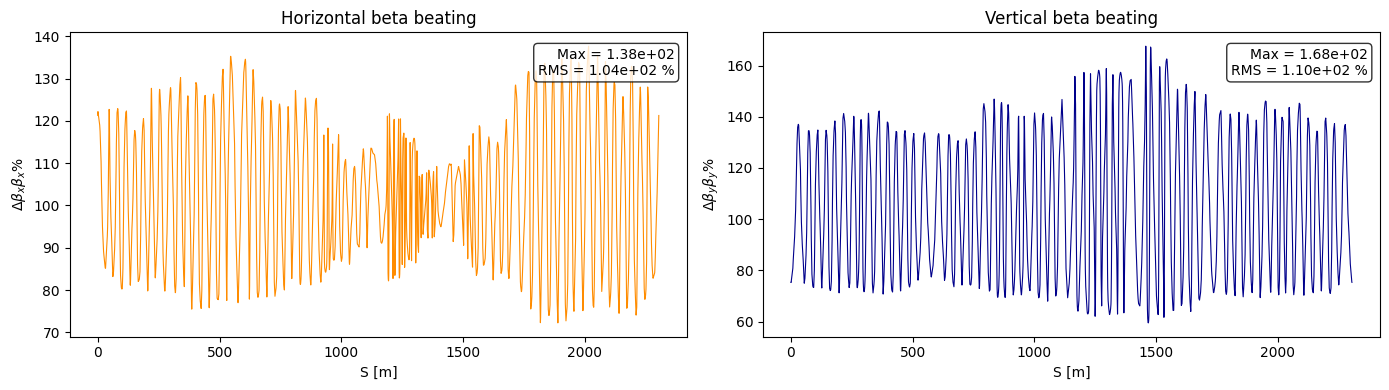

In [3]:
print('Lattice tune after loco :' , at.get_tune(ring))
_, _, twiss_err = at.get_optics(ring, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1]) / twiss.beta[:, 1]

plot_beta(s_pos, bx, by)

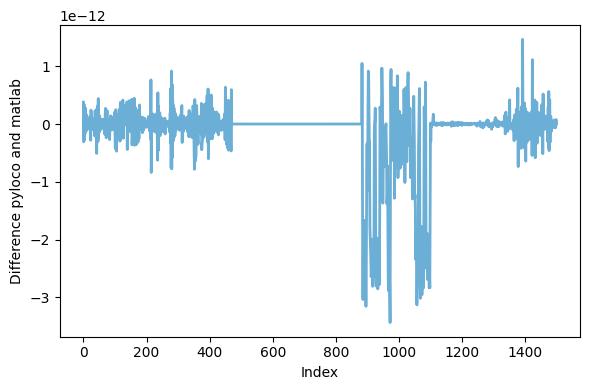

In [5]:
import matplotlib.pyplot as plt
fit_results_matlab = np.load('./data/matlab_fit_8iter.npy')
rel_diff = (fit_results_matlab - fit_results[len(fit_results)-1])
plt.figure(figsize=(6, 4))
plt.plot(rel_diff, color="#6baed6", lw=2)
plt.xlabel("Index")
plt.ylabel("Difference pyloco and matlab")
plt.tight_layout()
plt.show()